<a href="https://colab.research.google.com/github/UO294665/AAIM/blob/main/google_colab_files/Computer_Vision_Example_GAR0170.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# Importing libraries and dataset
import numpy as np
#from keras.utils import np_utils
from keras.datasets import fashion_mnist
import keras.utils as np_utils
import tensorflow as tf
import random as rd
tf.device('gpu')

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

%matplotlib inline
import matplotlib.pyplot as plt



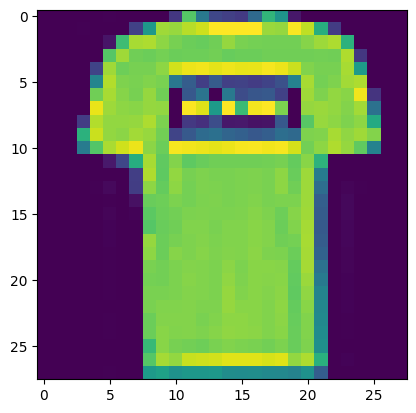

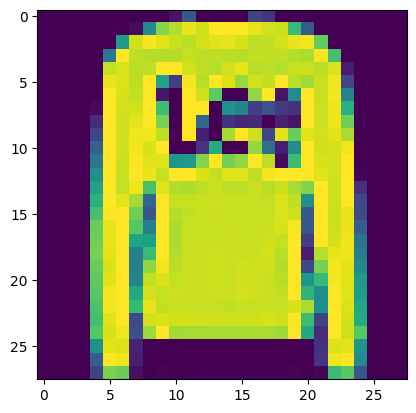

In [9]:
# Showing an example of the training sample
plt.imshow(X_train[1,:,:])
plt.show()

# Showing an example of the testing sample
plt.imshow(X_test[1,:,:])
plt.show()


In [11]:
# converting training and testing samples to float for pixels normalization

#Converting pixel values to floating points for all training and testing samples
X_train=X_train.astype('float32')
X_test=X_test.astype('float32')

# Dividing the training and testing samples by 255 for normalization
X_train/=255.0
X_test/=255.0

# Adding an extra dimension to feed to a 2D neural network model
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32')
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32')

# Converting labels to one hot encoders
y_train = np_utils.to_categorical(y_train, 10)
y_test = np_utils.to_categorical(y_test, 10)

In [12]:
# Defining layers used in the network (convolution, maxpooling, flatten, Dense and Dropout)
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout, Flatten, Reshape
from keras.layers import Convolution2D, MaxPooling2D

In [13]:
#Defining the model architecture
model = Sequential()
model.add(Convolution2D(32, 3, 3, input_shape=(28, 28, 1)))
model.add(Activation('relu'))
model.add(Dropout(0.25))

model.add(Convolution2D(32, 3, 3))
model.add(Activation('relu'))

model.add(Convolution2D(32, 3, 3))
model.add(Activation('relu'))
model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(128))
model.add(Dense(128))
model.add(Activation('relu'))

model.add(Dense(10))
model.add(Activation('softmax'))

# Model Compilation
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Model Training
model.fit(X_train, y_train, batch_size=32,epochs=10,validation_data=(X_test, y_test))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.6668 - loss: 0.8796 - val_accuracy: 0.8349 - val_loss: 0.4449
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8228 - loss: 0.4781 - val_accuracy: 0.8518 - val_loss: 0.3923
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.8412 - loss: 0.4277 - val_accuracy: 0.8575 - val_loss: 0.3775
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8493 - loss: 0.4045 - val_accuracy: 0.8615 - val_loss: 0.3733
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.8585 - loss: 0.3858 - val_accuracy: 0.8677 - val_loss: 0.3559
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8626 - loss: 0.3744 - val_accuracy: 0.8667 - val_loss: 0.3588
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.8660 - loss: 0.3592 - val_accuracy: 0.8736 - val_loss: 0.3462
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.8697 - loss: 0

In [14]:
print('Test accuracy:', model.evaluate(X_test, y_test))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8764 - loss: 0.3352
Test accuracy: [0.33958446979522705, 0.875]


** Model Training and Testing with Image Augmentation**

In [17]:
# Image Generators for image augmentations. For this particular example, we have used image rotation, horizontal and vertical flip along with width and height shift range
from keras.preprocessing.image import ImageDataGenerator

#Data Augmentation
datagen = ImageDataGenerator(

    featurewise_center=False,
    samplewise_center=False,
    featurewise_std_normalization=False,
    samplewise_std_normalization=False,
    zca_whitening=False,
    rotation_range=50,
    width_shift_range=0.01,
    height_shift_range=0.01,
    horizontal_flip=True,
    vertical_flip=True)

# Model Training with augmentation
datagen.fit(X_train)

# Showing an example of the augmented data (Rotated image)
gen = datagen.flow(X_train, batch_size=1)
plt.imshow(gen.next().squeeze())
plt.show()


In [ ]:
model.fit(X_train, y_train, batch_size=32,epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
1875/1875 [==============================] - 12s 6ms/step - loss: 0.2956 - accuracy: 0.8906 - val_loss: 0.3076 - val_accuracy: 0.8893
Epoch 2/10
1875/1875 [==============================] - 12s 6ms/step - loss: 0.2959 - accuracy: 0.8912 - val_loss: 0.3201 - val_accuracy: 0.8830
Epoch 3/10
1875/1875 [==============================] - 13s 7ms/step - loss: 0.2944 - accuracy: 0.8921 - val_loss: 0.3071 - val_accuracy: 0.8896
Epoch 4/10
1875/1875 [==============================] - 12s 7ms/step - loss: 0.2938 - accuracy: 0.8929 - val_loss: 0.2978 - val_accuracy: 0.8929
Epoch 5/10
1875/1875 [==============================] - 12s 7ms/step - loss: 0.2901 - accuracy: 0.8937 - val_loss: 0.3104 - val_accuracy: 0.8869
Epoch 6/10
1875/1875 [==============================] - 12s 6ms/step - loss: 0.2887 - accuracy: 0.8935 - val_loss: 0.3044 - val_accuracy: 0.8879
Epoch 7/10
1875/1875 [==============================] - 12s 6ms/step - loss: 0.2836 - accuracy: 0.8966 - val_loss: 0.2965 - val_ac

In [ ]:
print('Test accuracy:', model.evaluate(X_test, y_test))

313/313 [==============================] - 1s 2ms/step - loss: 0.3119 - accuracy: 0.8858
Test accuracy: [0.31192725896835327, 0.8858000040054321]
